## **SECTION 0 - Introduction**
### **Salary Prediction Model**
#### **Objective**
Predict salary from:

- Job metadata
- Extracted skills
#### **Dataset**
- jobs_cleaned.parquet
- skills.parquet
#### **Evaluation**
- MAE
- RMSE
#### **Models**
- Median baseline
- Title baseline
- Ridge
- LightGBM
#### **Reproducibility**
random_state = 42

## **SECTION 1 - Load Data**

In [1]:
!pip install lightgbm -q


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings
import logging
import joblib
import hashlib
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor

from src.processor import parse_experience
from src.feature_engineer import build_skill_aggregates
from src.evaluation import evaluate_model
from src.feature_engineer import get_skill_matrix
from src.evaluation import get_model_summary
from src.processor import group_rare_categories, clean_industry
warnings.filterwarnings("ignore")
logging.getLogger('lightgbm').setLevel(logging.ERROR)


In [3]:
# Thêm đường dẫn để import từ thư mục src
sys.path.append(os.path.abspath(os.path.join('..')))

jobs = pd.read_parquet("../data/processed/jobs_cleaned.parquet")
skills = pd.read_parquet("../data/processed/skills.parquet")

print(jobs.shape)
print(skills.shape)

(3181, 24)
(56335, 8)


## **SECTION 2 - Data Quality Check**
**Mục tiêu:** Trả lời cho các câu hỏi: 
*   Có bao nhiêu jobs?
*   Có bao nhiêu skills?
*   Coverage bao nhiêu?
*   Có bị duplicate không?

In [4]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3181 entries, 0 to 3180
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   job_id                     3181 non-null   int64  
 1   url                        3181 non-null   object 
 2   job_title                  3181 non-null   object 
 3   company                    3181 non-null   object 
 4   location                   3177 non-null   object 
 5   salary                     3181 non-null   object 
 6   experience                 3181 non-null   object 
 7   education                  3181 non-null   object 
 8   job_level                  3181 non-null   object 
 9   employment_type            3181 non-null   object 
 10  industry                   3112 non-null   object 
 11  platform_required_skills   3181 non-null   object 
 12  platform_preferred_skills  2440 non-null   object 
 13  specialization             2440 non-null   objec

In [5]:
skills.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56335 entries, 0 to 56334
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_id           56335 non-null  int64  
 1   skill_name       56335 non-null  object 
 2   final_canonical  56335 non-null  object 
 3   label            56335 non-null  object 
 4   category         56335 non-null  object 
 5   level            10993 non-null  object 
 6   min_years        3813 non-null   Float64
 7   source_text      56335 non-null  object 
dtypes: Float64(1), int64(1), object(6)
memory usage: 3.5+ MB


In [6]:
jobs.isna().mean().sort_values()

job_id                       0.000000
url                          0.000000
job_title                    0.000000
company                      0.000000
salary                       0.000000
experience                   0.000000
education                    0.000000
job_level                    0.000000
job_description              0.000000
employment_type              0.000000
platform_required_skills     0.000000
requirement                  0.000000
max_salary                   0.000000
min_salary                   0.000000
source                       0.000000
standardized_title           0.000000
avg_salary                   0.000000
is_null_salary               0.000000
is_thoa_thuan                0.000000
is_missing_salary            0.000000
location                     0.001257
industry                     0.021691
platform_preferred_skills    0.232946
specialization               0.232946
dtype: float64

In [7]:
skills.isna().mean().sort_values()

job_id             0.000000
skill_name         0.000000
final_canonical    0.000000
label              0.000000
category           0.000000
source_text        0.000000
level              0.804864
min_years          0.932316
dtype: float64

In [8]:
jobs.duplicated().sum()
skills.duplicated().sum()

np.int64(0)

## **SECTION 3 - Target Engineering**

###  **3.1 Negotiable Analysis**

**Research Question 1: Can negotiable jobs be removed safely?**

In [9]:
jobs.groupby("is_thoa_thuan")["source"].value_counts(normalize=True)

is_thoa_thuan  source
False          topcv     0.879567
               itviec    0.120433
True           topcv     0.669407
               itviec    0.330593
Name: proportion, dtype: float64

In [10]:
jobs.groupby("is_thoa_thuan")["job_level"].value_counts(normalize=True)

is_thoa_thuan  job_level         
False          Nhân viên             0.609608
               Trưởng nhóm           0.217185
               Intern                0.074425
               Senior                0.041949
               Quản lý / Giám sát    0.031800
               Trưởng/Phó phòng      0.018268
               Junior                0.004060
               Giám đốc              0.002030
               Fresher               0.000677
True           Nhân viên             0.597769
               Trưởng nhóm           0.159131
               Senior                0.112155
               Quản lý / Giám sát    0.049325
               Intern                0.032883
               Trưởng/Phó phòng      0.030534
               Junior                0.012918
               Giám đốc              0.003523
               Fresher               0.001762
Name: proportion, dtype: float64

**Nhận xét: Phân tích nhóm công việc có mức lương thỏa thuận**

Hơn 50% tin tuyển dụng trong tập dữ liệu được gắn nhãn **lương thỏa thuận (negotiable)**.

Khi so sánh giữa nhóm có công bố lương và nhóm thỏa thuận, phân bố dữ liệu cho thấy một số khác biệt đáng chú ý:

* ITViec có tỷ lệ tin tuyển dụng thỏa thuận cao hơn so với TopCV.
* Các vị trí cấp cao như **Senior**, **Quản lý/Giám sát** và **Trưởng/Phó phòng** xuất hiện với tỷ lệ cao hơn trong nhóm thỏa thuận.
* Ngược lại, các vị trí **Intern** và **Trưởng nhóm** xuất hiện nhiều hơn trong nhóm có công bố mức lương cụ thể.

Điều này cho thấy việc loại bỏ các tin tuyển dụng thỏa thuận có thể tạo ra **selection bias** (thiên lệch chọn mẫu), do nhóm bị loại bỏ không có cùng phân bố với nhóm còn lại.

Tuy nhiên, bài toán dự đoán lương yêu cầu biến mục tiêu phải có giá trị số. Do các tin tuyển dụng thỏa thuận không cung cấp mức lương cụ thể nên không thể sử dụng trực tiếp làm dữ liệu huấn luyện. Vì vậy, các quan sát này được loại bỏ khỏi tập modeling.

Đây là một hạn chế của bộ dữ liệu và cần được ghi nhận trong phần đánh giá dữ liệu (Datasheet), đặc biệt vì nhóm bị loại bỏ chứa tỷ lệ tương đối cao các vị trí có kinh nghiệm và cấp bậc cao.


> Tỷ lệ vị trí **Senior** trong nhóm thỏa thuận (11.2%) cao hơn đáng kể so với nhóm có công bố lương (4.2%), cho thấy các công việc có mức lương cao thường ít công khai mức lương hơn.



### **Decision 1**

In [11]:
jobs_model = jobs[jobs["is_thoa_thuan"] == False].copy()

In [12]:
# Số lượng data còn lại
jobs_model.shape

(1478, 24)

In [13]:
jobs_model["avg_salary"].describe(
    percentiles=[
        0.90,
        0.95,
        0.97,
        0.99,
        0.995
    ]
)

count      1478.000000
mean        236.848241
std        7217.937359
min           0.000000
50%          22.500000
90%          47.500000
95%          56.250000
97%          63.231400
99%          75.000000
99.5%        86.037800
max      275000.000000
Name: avg_salary, dtype: float64

<Axes: >

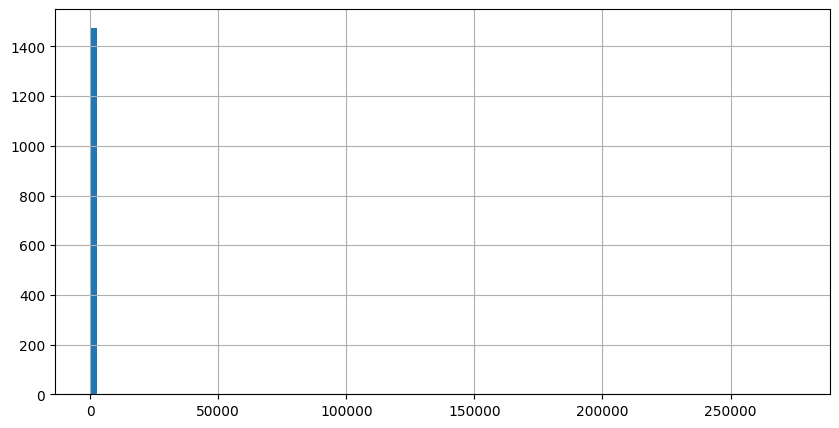

In [14]:
jobs_model["avg_salary"].hist(bins=100,figsize=(10,5))

In [15]:
(
    jobs_model["avg_salary"] == 0
).sum()

np.int64(2)

In [16]:
(
    jobs_model["avg_salary"] == 0
).mean()

np.float64(0.0013531799729364006)

In [17]:
jobs_model[jobs_model["avg_salary"] == 0][
    [
        "salary",
        "avg_salary",
        "is_missing_salary",
        "is_null_salary"
    ]
].head(20)

,salary,avg_salary,is_missing_salary,is_null_salary
1019,Tới 0.0 triệu,0.0,True,False
1795,0.0 - 0.0 triệu,0.0,True,False


In [18]:
jobs_model.nlargest(20,"avg_salary")[
    [
        "job_title",
        "salary",
        "min_salary",
        "max_salary",
        "avg_salary",
        "source"
    ]
]

,job_title,salary,min_salary,max_salary,avg_salary,source
1848,Nhân Viên Idea Creator (Mảng POD - AI),"10,000,000 - 12,000,000 USD",250000.00,300000.00,275000.00,topcv
1602,Chuyên Viên SRE,"Tới 1,500,000 USD",0.00,37500.00,37500.00,topcv
3139,Solution Architect - Salary Up to $5000,Up to $5000,0.00,125.00,125.00,itviec
2082,Technical Manager (SaaS),"Tới 4,000 USD",0.00,100.00,100.00,topcv
3175,VIETTEL SOLUTIONS - Solutions Architect,"2,500 - 5,000 USD",62.50,125.00,93.75,itviec
2716,(HN) Expert/Manager Software Engineering,"3,000 - 4,000 USD",75.00,100.00,87.50,itviec
3155,Technical Lead (Golang) ~ Upto 3500$,Upto 3500$,0.00,87.50,87.50,itviec
3174,VIETTEL SOLUTIONS - Project Manager,"2,000 - 4,998 USD",50.00,124.95,87.47,itviec
2723,[HYBRID] Senior Java Developer,"3,200 - 3,500 USD",80.00,87.50,83.75,itviec
3092,Senior Python Developer,"3,200 - 3,500 USD",80.00,87.50,83.75,itviec


In [19]:
jobs_model[jobs_model["avg_salary"] > 500][
    [
        "job_title",
        "salary",
        "avg_salary",
        "source"
    ]
]

,job_title,salary,avg_salary,source
1602,Chuyên Viên SRE,"Tới 1,500,000 USD",37500.0,topcv
1848,Nhân Viên Idea Creator (Mảng POD - AI),"10,000,000 - 12,000,000 USD",275000.0,topcv


In [20]:
bad_salary_mask = jobs_model["avg_salary"] > 500

In [21]:
jobs_model = jobs_model.loc[~bad_salary_mask].copy()

In [22]:
jobs_model["avg_salary"].describe(
    percentiles=[
        .90,
        .95,
        .97,
        .99,
        .995
    ]
)

count    1476.000000
mean       25.448306
std        15.772460
min         0.000000
50%        22.500000
90%        47.500000
95%        56.250000
97%        62.500000
99%        75.000000
99.5%      82.812500
max       125.000000
Name: avg_salary, dtype: float64

<Axes: >

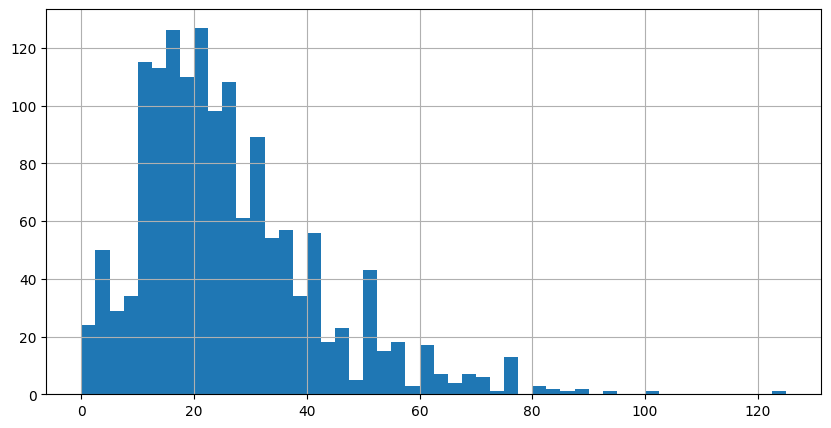

In [23]:
jobs_model["avg_salary"].hist(bins=50,figsize=(10,5))

**Kết luận**
Việc loại bỏ các tin tuyển dụng có mức lương thỏa thuận tạo ra một mức độ thiên lệch chọn mẫu (selection bias), đặc biệt đối với nguồn dữ liệu ITViec và các vị trí có kinh nghiệm hoặc cấp bậc cao.

Tuy nhiên, bài toán dự đoán lương yêu cầu biến mục tiêu phải có giá trị số cụ thể để huấn luyện mô hình. Do đó, các tin tuyển dụng không công bố mức lương được loại khỏi tập dữ liệu modeling. Hạn chế này được ghi nhận và thảo luận trong phần đánh giá dữ liệu.

### **Hướng đi tiếp**
Sau khi loại bỏ các lỗi rõ ràng trong quá trình trích xuất và chuẩn hóa mức lương, phân phối lương còn lại được đánh giá là tương đối hợp lý và phản ánh đúng thực tế thị trường lao động CNTT.

Khoảng cách giữa phân vị 99% (75 triệu đồng) và giá trị lớn nhất (125 triệu đồng) không quá lớn, đồng thời các mức lương cao vẫn có thể đại diện cho những vị trí quản lý hoặc chuyên gia cấp cao.

Vì vậy, nghiên cứu quyết định **không áp dụng winsorization**, nhằm giữ nguyên các quan sát có giá trị lương cao và bảo toàn tối đa thông tin của bộ dữ liệu.

In [24]:
jobs_model["log_salary"] = np.log1p(jobs_model["avg_salary"])

In [25]:
jobs_model["log_salary"].describe()

count    1476.000000
mean        3.088477
std         0.658041
min         0.000000
25%         2.772589
50%         3.157000
75%         3.511545
max         4.836282
Name: log_salary, dtype: float64

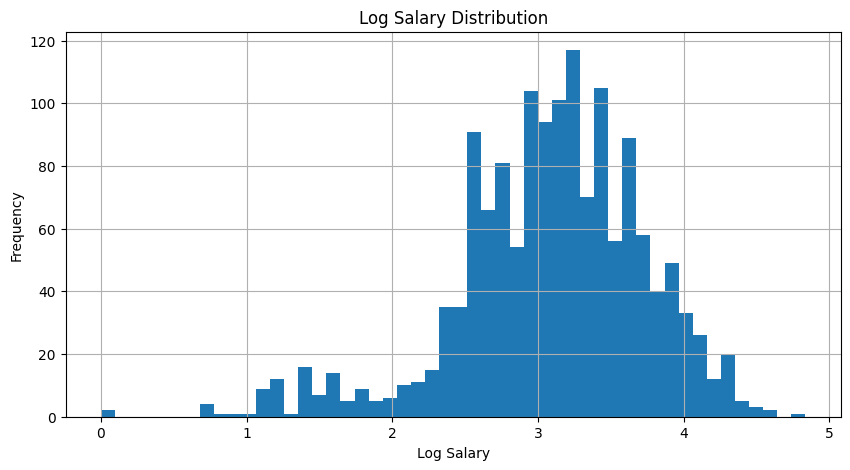

In [26]:
jobs_model["log_salary"].hist(bins=50,figsize=(10,5))
plt.title("Log Salary Distribution")
plt.xlabel("Log Salary")
plt.ylabel("Frequency")
plt.show()

In [27]:
TARGET = "log_salary"

## **SECTION 4 - Job Metadata Features**

### **4.1 Cardinality Analysis**

In [28]:
job_features = [
    "source",
    "location",
    "industry",
    "specialization",
    "education",
    "experience",
    "job_level",
    "standardized_title"
]

for col in job_features:
    print(f"{col}: {jobs_model[col].nunique()}")

source: 2
location: 18
industry: 55
specialization: 1154
education: 8
experience: 17
job_level: 9
standardized_title: 97


**Phân tích từng feature**

*1. source:* Giữ nguyên, OneHot: source_topcv & source_itviec.

*2. location:* Giữ nguyên, OneHot trực tiếp, không cần gộp.

*3. education:* Giữ nguyên.

*4. education:* Không OneHot => convert thành numeric.

*5. specialization:*

*6. job_level:* Giữ nguyên.

*7. industry:*

*8. standardized_title:* Giữ nguyên.

### **4.2 Experience Engineering**

In [29]:
jobs_model["experience"].value_counts()

experience
2 năm            341
3 năm            326
1 năm            310
Không yêu cầu    135
Dưới 1 năm       120
4 năm             82
5 năm             76
Trên 5 năm        34
Trên 3 năm        27
Trên 4 năm         9
7 năm              5
Trên 7 năm         3
Trên 2 năm         3
6 năm              2
Trên 1 năm         1
Trên 8 năm         1
Trên 9 năm         1
Name: count, dtype: int64

**Quyết định xử lý:**

Kinh nghiệm làm việc ban đầu được lưu dưới dạng nhãn văn bản
(ví dụ: "1 năm", "Trên 3 năm", "Không yêu cầu").

Để bảo toàn tính thứ tự của biến này, kinh nghiệm được chuyển đổi
thành biến số `experience_years` thay vì sử dụng One-Hot Encoding.

**Convert experience → experience_years**

In [30]:
# Gọi hàm từ src.processor
jobs_model["experience_years"] = jobs_model["experience"].apply(parse_experience)

# Kiểm tra kết quả
print(jobs_model["experience_years"].describe())

count    1476.000000
mean        2.138550
std         1.498116
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         9.500000
Name: experience_years, dtype: float64


In [31]:
jobs_model["experience_years"].describe()

count    1476.000000
mean        2.138550
std         1.498116
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         9.500000
Name: experience_years, dtype: float64

In [32]:
jobs_model["experience_years"].value_counts().sort_index()

experience_years
0.0    135
0.5    120
1.0    310
1.5      1
2.0    341
2.5      3
3.0    326
3.5     27
4.0     82
4.5      9
5.0     76
5.5     34
6.0      2
7.0      5
7.5      3
8.5      1
9.5      1
Name: count, dtype: int64

### **4.3 Industry Handling**

**Khảo sát và Tối ưu hóa biến Industry**

Biến `industry` ban đầu chứa thông tin ngành nghề rất chi tiết nhưng lại phân mảnh mạnh. Nhóm thực hiện khảo sát số lượng danh mục để xác định vấn đề dữ liệu thưa (Sparsity) và đưa ra quyết định gộp nhóm.

In [33]:
n_original = jobs_model["industry"].nunique()
print(f"Số lượng ngành nghề ban đầu: {n_original}")
print("\nTop 20 ngành nghề phổ biến nhất:")
print(jobs_model["industry"].value_counts().head(20))

counts = jobs_model["industry"].value_counts()
print(f"\nSố lượng ngành chỉ có dưới 5 tin tuyển dụng: {(counts < 5).sum()}")
print(f"Số lượng ngành chỉ có dưới 15 tin tuyển dụng: {(counts < 15).sum()}")

Số lượng ngành nghề ban đầu: 55

Top 20 ngành nghề phổ biến nhất:
industry
IT - Phần mềm                            835
Giáo dục / Đào tạo                        54
IT Services and IT Consulting             49
Marketing / Truyền thông / Quảng cáo      47
Khác                                      35
Software Products and Web Services        32
Bán lẻ - Hàng tiêu dùng - FMCG            31
Viễn thông                                29
Sản xuất                                  27
Thương mại điện tử                        25
Financial Services                        22
Dược phẩm / Y tế / Công nghệ sinh học     21
IT - Phần cứng                            20
Tài chính                                 16
Software Development Outsourcing          14
Banking                                   14
Bất động sản                              14
Giải trí                                  13
Logistics - Vận tải                       11
Xây dựng                                  10
Name: count, dtype: int64

In [34]:
# Khảo sát sự thay đổi số lượng nhóm ngành theo các ngưỡng gộp khác nhau
for k in [5, 10, 15, 20]:
    temp = group_rare_categories(jobs_model["industry"], min_freq=k)
    print(f"Ngưỡng min_freq={k} => Số lượng nhóm ngành còn lại: {temp.nunique()}")

Ngưỡng min_freq=5 => Số lượng nhóm ngành còn lại: 34
Ngưỡng min_freq=10 => Số lượng nhóm ngành còn lại: 22
Ngưỡng min_freq=15 => Số lượng nhóm ngành còn lại: 15
Ngưỡng min_freq=20 => Số lượng nhóm ngành còn lại: 14


**Nhận xét và Quyết định**

Kết quả khảo sát cho thấy biến `industry` có mức độ phân mảnh cao với nhiều ngành chỉ xuất hiện rất ít lần.

* Các ngưỡng min_freq thấp (5–10) vẫn giữ lại khá nhiều nhóm ngành, dẫn đến dữ liệu One-Hot tương đối thưa.
* Ngưỡng min_freq=15 giúp giảm đáng kể số lượng danh mục nhưng vẫn giữ được các ngành xuất hiện thường xuyên nhất.
* Ngưỡng min_freq=20 tiếp tục giảm số nhóm nhưng mức cải thiện không đáng kể so với ngưỡng 15.

**Quyết định:** sử dụng `min_freq=15` để tạo biến `industry_cleaned`. Các ngành xuất hiện dưới 15 lần được gộp vào nhóm `Other`.

Cách xử lý này giúp giảm hiện tượng high-cardinality, hạn chế sparsity sau One-Hot Encoding và tăng độ ổn định của mô hình.

### **4.3.1 Tiền xử lý và Gộp nhóm (Feature Engineering)**

In [35]:
# Chuẩn hóa tên ngành nghề (Xử lý khoảng trắng, định dạng...)
jobs_model['industry'] = clean_industry(jobs_model['industry'])
# Gộp nhóm theo ngưỡng 15 đã quyết định
jobs_model['industry_cleaned'] = group_rare_categories(jobs_model['industry'], min_freq=15)

print(f"Số lượng ngành nghề ban đầu: {jobs_model['industry'].nunique()}")
print(f"Số lượng ngành nghề sau khi gộp: {jobs_model['industry_cleaned'].nunique()}")

Số lượng ngành nghề ban đầu: 56
Số lượng ngành nghề sau khi gộp: 15


#### **4.3.2 Trực quan hóa mức lương theo ngành (Insights)**

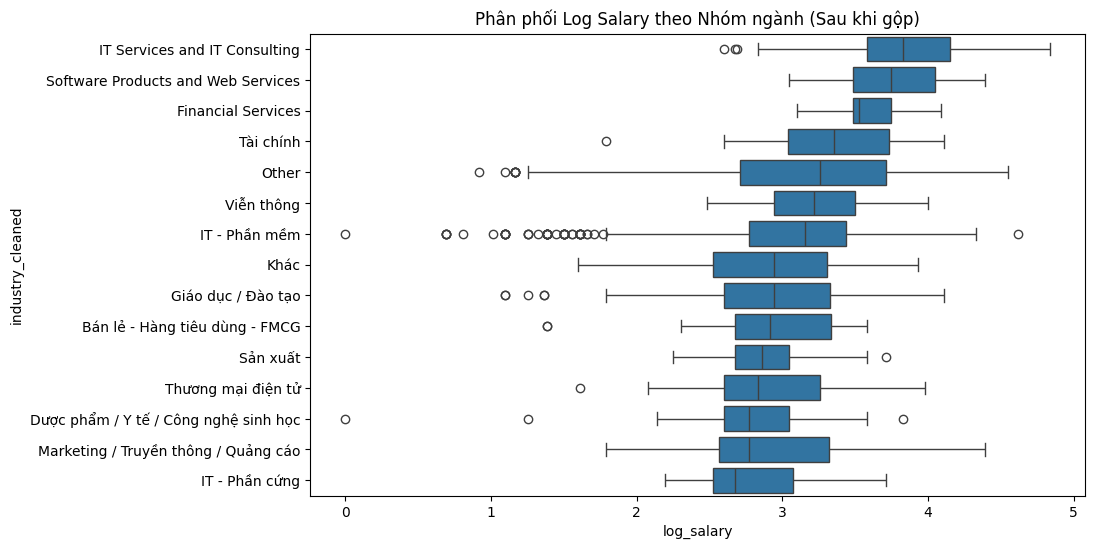

In [36]:
plt.figure(figsize=(10, 6))
order = jobs_model.groupby('industry_cleaned')['log_salary'].median().sort_values(ascending=False).index
sns.boxplot(data=jobs_model, x='log_salary', y='industry_cleaned', order=order)
plt.title("Phân phối Log Salary theo Nhóm ngành (Sau khi gộp)")
plt.show()

### **Job Metadata Feature Set cuối cùng**

Sau quá trình khảo sát và tối ưu hóa, biến `industry_cleaned` được sử dụng thay thế cho `industry` gốc nhằm giảm số lượng danh mục hiếm và hạn chế hiện tượng sparsity.

Tính nhất quán: Bộ tính năng này sẽ là nền tảng (Feature Set A) để so sánh với các bộ tính năng bổ sung kỹ năng (Feature Set B) ở các phần tiếp theo.

In [37]:
NUMERIC_FEATURES = ["experience_years"]
CATEGORICAL_FEATURES = [
    "source",
    "location",
    "education",
    "job_level",
    "industry_cleaned", # Đã tối ưu từ 56 về 15 nhóm
    "standardized_title"
]
# Các cột bị loại bỏ
EXCLUDED = ["specialization", "industry"]

## **SECTION 5 - Skill Feature Engineering**

### **5.1 Skill Overview**

In [38]:
skills["final_canonical"].nunique()

2762

**Nhận xét:**
1476 jobs

2762 canonical skills

=> Số skill unique > số job

=> `Không thể` OneHot toàn bộ skill

In [39]:
skills["category"].value_counts()

category
Soft Skill                              8740
Infrastructure & DevOps                 8023
Engineering Concepts & Methodologies    7822
Tool & Platform                         5601
Domain Knowledge                        5026
Programming Language                    3296
Framework / Library                     3229
Database                                2867
AI/ML/Data                              2625
Testing & QA                            2574
Other                                   2259
Data Engineering & Analytics            1870
Design & UX                             1092
Embedded & Firmware                      693
IT Support & Hardware                    618
Name: count, dtype: int64

In [40]:
skills["level"].value_counts(dropna=False)

level
None            45342
expert           5684
basic            2761
intermediate     2548
Name: count, dtype: int64

**Nhận xét:** 
Không nên dùng `expert/basic/intermediate` theo dạng OneHot skill-level

Thay vào đó, ta tạo **aggregate feature**.

Ví dụ: 
*   n_expert_skills
*   n_intermediate_skills
*   n_basic_skills

In [41]:
skills.groupby("job_id").size().describe()

count    3168.000000
mean       17.782513
std        10.321469
min         1.000000
25%        10.000000
50%        16.000000
75%        23.000000
max        86.000000
dtype: float64

### **5.2 Build Aggregate Features**
**Mục tiêu:** từ skills -> skill_agg

> Tín hiệu liên quan đến kỹ năng đơn giản nhất là tổng số kỹ năng được đề cập trong một tin tuyển dụng.

> Nhóm giả thuyết rằng các vị trí có mức độ senior cao hơn và mức lương cao hơn thường yêu cầu phạm vi kỹ năng rộng hơn, do đó số lượng kỹ năng có thể mang thông tin hữu ích cho việc dự đoán lương.

In [42]:
# Gom tất cả logic phức tạp vào 1 hàm duy nhất từ src.feature_engineer
skill_agg = build_skill_aggregates(skills)

# Merge vào jobs_model như cũ
model_base = jobs_model.merge(skill_agg, on="job_id", how="left")

# Xử lý NA cho các cột skill vừa merge
skill_feature_cols = [c for c in skill_agg.columns if c != "job_id"]
model_base[skill_feature_cols] = model_base[skill_feature_cols].fillna(0)
print(f"Kết quả model_base sau khi merge skill: {model_base.shape}")

Kết quả model_base sau khi merge skill: (1476, 50)


#### **5.2.1 Kiểm tra output**

In [43]:
skill_agg.shape

(3168, 24)

In [44]:
skill_agg.head()

,job_id,n_skills,n_preferred,n_required,cat_ai_ml_data,cat_data_engineering_&_analytics,cat_database,cat_design_&_ux,cat_domain_knowledge,cat_embedded_&_firmware,...,cat_other,cat_programming_language,cat_soft_skill,cat_testing_&_qa,cat_tool_&_platform,level_basic,level_expert,level_intermediate,required_experience_level,has_year_requirement
0,1,19,1,18,0,0,3,0,3,0,...,1,3,4,0,0,1.0,0.0,1.0,0.0,0
1,2,9,2,7,0,0,0,0,2,0,...,0,2,1,0,0,0.0,0.0,0.0,0.0,0
2,3,21,0,21,0,2,3,0,4,0,...,0,1,2,0,0,0.0,2.0,0.0,0.0,0
3,4,24,5,19,0,0,1,0,1,0,...,0,0,1,0,1,0.0,3.0,2.0,1.0,1
4,5,19,8,11,0,0,0,0,3,0,...,5,0,7,0,0,0.0,1.0,0.0,3.0,1


In [45]:
skill_agg.describe()

,job_id,n_skills,n_preferred,n_required,cat_ai_ml_data,cat_data_engineering_&_analytics,cat_database,cat_design_&_ux,cat_domain_knowledge,cat_embedded_&_firmware,...,cat_other,cat_programming_language,cat_soft_skill,cat_testing_&_qa,cat_tool_&_platform,level_basic,level_expert,level_intermediate,required_experience_level,has_year_requirement
count,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.00000,...,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.000000,3168.0,3168.000000
mean,1593.160354,17.782513,3.900568,13.881944,0.828598,0.590278,0.904987,0.344697,1.586490,0.21875,...,0.713068,1.040404,2.758838,0.812500,1.767992,0.871528,1.794192,0.804293,1.788984,0.612689
std,918.813377,10.321469,4.460389,8.527780,2.950702,1.946569,1.660895,1.312252,2.177931,1.55840,...,1.608136,1.481262,2.278644,2.476707,2.231649,1.857125,2.709478,2.027959,1.964282,0.487213
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,796.750000,10.000000,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,1594.500000,16.000000,3.000000,12.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,...,0.000000,0.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.0,1.000000
75%,2389.250000,23.000000,6.000000,18.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.00000,...,1.000000,2.000000,4.000000,0.000000,3.000000,1.000000,3.000000,1.000000,3.0,1.000000
max,3181.000000,86.000000,37.000000,80.000000,33.000000,24.000000,16.000000,27.000000,17.000000,27.00000,...,20.000000,9.000000,17.000000,27.000000,19.000000,24.000000,25.000000,49.000000,13.0,1.000000


#### **5.2.2 Merge vào jobs_model**

In [46]:
model_base = (jobs_model.merge(skill_agg,on="job_id",how="left"))

In [47]:
# Check 
model_base.shape

(1476, 50)

In [48]:
model_base.head()

,job_id,url,job_title,company,location,salary,experience,education,job_level,employment_type,...,cat_other,cat_programming_language,cat_soft_skill,cat_testing_&_qa,cat_tool_&_platform,level_basic,level_expert,level_intermediate,required_experience_level,has_year_requirement
0,1,https://www.topcv.vn/viec-lam/lap-trinh-vien-n...,Lập Trình Viên (.Net) - Không Yêu Cầu Kinh Ngh...,Công ty cổ phần công nghệ và giải pháp trực tu...,Hà Nội,8 - 20 triệu,2 năm,Đại Học trở lên,Nhân viên,Toàn thời gian,...,1.0,3.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,3,https://www.topcv.vn/viec-lam/backend-lead-eng...,Backend Lead Engineer,CÔNG TY TNHH LEVER SPHERE VIỆT NAM,Hà Nội,50 - 70 triệu,3 năm,Đại Học trở lên,Trưởng nhóm,Toàn thời gian,...,0.0,1.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
2,4,https://www.topcv.vn/viec-lam/lap-trinh-vien-n...,Lập Trình Viên Nodejs Đi Làm Ngay Tại Hà Nội,Công ty cổ phần giải pháp MKT,Hà Nội,Tới 30 triệu,1 năm,Đại Học trở lên,Nhân viên,Toàn thời gian,...,0.0,0.0,1.0,0.0,1.0,0.0,3.0,2.0,1.0,1.0
3,5,https://www.topcv.vn/viec-lam/ky-su-tu-van-man...,Kỹ Sư Tư Vấn Mạng/ Presale Network Engineer,Công ty Cổ phần Viễn thông - Tin học Bưu điện ...,Hà Nội,Tới 45 triệu,3 năm,Cao Đẳng trở lên,Nhân viên,Toàn thời gian,...,5.0,0.0,7.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0
4,6,https://www.topcv.vn/viec-lam/nhan-vien-ky-thu...,Nhân Viên Kỹ Thuật IT - Dự Án Xây Dựng Cao Tần...,"CÔNG TY CỔ PHẦN XÂY DỰNG, THƯƠNG MẠI VÀ VẬT LI...",Hưng Yên,Tới 15 triệu,2 năm,Cao Đẳng trở lên,Nhân viên,Toàn thời gian,...,0.0,0.0,2.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0


**CheckPoint 1**
**Mục tiêu:** Xem còn missing nào không.

In [49]:
model_base.isna().sum().sort_values(ascending=False).head(30)

specialization                              178
platform_preferred_skills                   178
cat_domain_knowledge                          8
cat_embedded_&_firmware                       8
cat_engineering_concepts_&_methodologies      8
cat_framework___library                       8
cat_it_support_&_hardware                     8
cat_infrastructure_&_devops                   8
cat_other                                     8
cat_programming_language                      8
cat_soft_skill                                8
n_skills                                      8
n_required                                    8
n_preferred                                   8
cat_database                                  8
cat_data_engineering_&_analytics              8
cat_design_&_ux                               8
cat_ai_ml_data                                8
level_expert                                  8
cat_testing_&_qa                              8
cat_tool_&_platform                     

**Nhận xét:**

Sự xuất hiện của các đặc trưng kỹ năng mới: Các cột bắt đầu bằng `n_`, `cat_`, và `level_` đã được tạo thành công. Đây là kết quả của quá trình gom nhóm và định lượng kỹ năng từ tập dữ liệu thô.

**Vấn đề Missing Values (Số lượng 8):** Có đúng 8 bản ghi bị thiếu dữ liệu đồng loạt ở tất cả các cột kỹ năng. Điều này xảy ra do 8 tin tuyển dụng này không chứa thông tin kỹ năng hoặc pipeline trích xuất không tìm thấy từ khóa phù hợp.

* **Giải pháp:** Nhóm sẽ xử lý bằng cách điền giá trị 0 (fillna(0)), coi như các công việc này không yêu cầu kỹ năng chuyên biệt hoặc dữ liệu kỹ năng không có sẵn.

**Các cột Metadata thô:** Các cột như `specialization` và `platform_preferred_skills` vẫn còn giá trị thiếu lớn (178 dòng).

* **Giải pháp:** Tuy nhiên, đây là các cột dữ liệu gốc không mang tính cấu trúc cao. Nhóm đã quyết định loại bỏ (DROP) các cột này ở bước chuẩn bị dữ liệu cuối cùng để tránh gây nhiễu cho mô hình.

In [50]:
# Xác định danh sách các cột đặc trưng kỹ năng (bắt đầu bằng n_, cat_, level_)
skill_feature_cols = [c for c in model_base.columns if c.startswith(('n_', 'cat_', 'level_'))]

# Xử lý triệt để 8 dòng thiếu bằng giá trị 0
model_base[skill_feature_cols] = model_base[skill_feature_cols].fillna(0)

# Xử lý location 
model_base["location"] = model_base["location"].fillna("Unknown")
model_base["has_year_requirement"] = model_base["has_year_requirement"].fillna(0).astype(int)
model_base["required_experience_level"] = model_base["required_experience_level"].fillna(0.0).astype(float)


In [51]:
model_base.isna().sum().sort_values(ascending=False).head(30)

specialization               178
platform_preferred_skills    178
url                            0
job_id                         0
job_title                      0
company                        0
experience                     0
education                      0
location                       0
salary                         0
employment_type                0
job_level                      0
platform_required_skills       0
industry                       0
job_description                0
requirement                    0
standardized_title             0
source                         0
min_salary                     0
max_salary                     0
avg_salary                     0
is_null_salary                 0
is_thoa_thuan                  0
is_missing_salary              0
log_salary                     0
experience_years               0
industry_cleaned               0
n_skills                       0
n_preferred                    0
n_required                     0
dtype: int

### **Chuẩn bị tập dữ liệu cho mô hình**

Các cột văn bản thô và những trường dữ liệu không sử dụng được loại bỏ trước khi huấn luyện mô hình.

Chỉ các đặc trưng có cấu trúc được giữ lại nhằm đảm bảo khả năng tái lập kết quả (reproducibility) và tránh nguy cơ rò rỉ thông tin ngoài ý muốn từ các trường văn bản tự do (free-text content). Biến `industry_cleaned` được giữ lại và thay thế hoàn toàn cho biến `industry` gốc trong toàn bộ các bước mô hình hóa tiếp theo.

In [52]:
DROP_COLS = [
    "url",
    "salary",
    "job_description",
    "requirement",
    "platform_required_skills",
    "platform_preferred_skills",
    "specialization", 
    "industry"
]
model_ready = (model_base.drop(columns=DROP_COLS,errors="ignore"))

### **Validation**

In [53]:
model_ready.shape

(1476, 42)

In [54]:
missing_after_clean = model_ready.isna().sum().sum()
print("Total missing values:", missing_after_clean)

Total missing values: 0


### **5.4 Build features_wide.parquet**

In [55]:
model_ready.to_parquet("../data/processed/features_wide_1.parquet",index=False)

In [56]:
pd.read_parquet("../data/processed/features_wide_1.parquet").shape

(1476, 42)

## **SECTION 06 - Modeling Setup**

### **6.1 Xác định biến mục tiêu (Target)**

Biến mục tiêu dùng để dự đoán là `average salary`.

Phân phối lương thường *lệch phải mạnh (highly right-skewed)*, do đó áp dụng phép biến đổi logarit để làm giảm độ lệch của dữ liệu.

**Mô hình sẽ dự đoán**:

`log_salary = log(1 + avg_salary)`

Phép biến đổi này giúp giảm ảnh hưởng của các giá trị lương quá cao (outliers), đồng thời cải thiện độ ổn định và khả năng học của mô hình.

In [57]:
model_ready["log_salary"] = np.log1p(model_ready["avg_salary"])

### **Validation**

In [58]:
model_ready[["avg_salary","log_salary"]].head()

,avg_salary,log_salary
0,14.0,2.708050
1,60.0,4.110874
2,30.0,3.433987
3,45.0,3.828641
4,15.0,2.772589


### **Distribution Check**

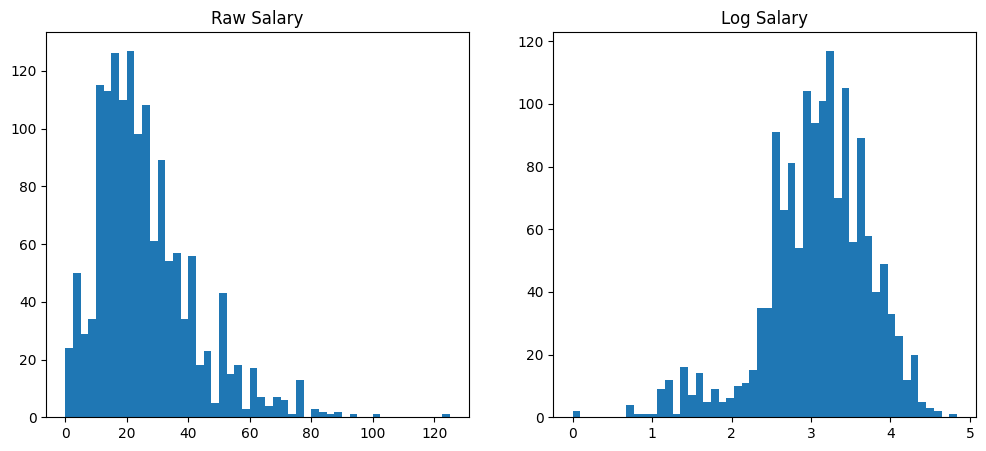

In [59]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].hist(model_ready["avg_salary"],bins=50)
ax[0].set_title("Raw Salary")
ax[1].hist(model_ready["log_salary"],bins=50)
ax[1].set_title("Log Salary")
plt.show()

### **6.2 Chiến lược phân tầng (Stratified Cross-Validation)**

Về lý thuyết, quá trình Cross-Validation nên được phân tầng đồng thời theo **nhóm lương (salary quantile)** và **nguồn dữ liệu (source)**.

Tuy nhiên, một số tổ hợp giữa nguồn dữ liệu và nhóm lương có số lượng mẫu quá ít (ví dụ: các tin tuyển dụng từ ITViec thuộc nhóm lương thấp nhất chỉ chiếm rất ít quan sát), khiến việc phân tầng đồng thời theo cả hai biến không khả thi khi sử dụng 5-fold Cross-Validation.

Do đó, đánh giá cuối cùng được thực hiện bằng cách **phân tầng theo nhóm lương** (`salary_bin`) nhằm đảm bảo phân phối mức lương tương đồng giữa các fold.

Trong khi đó, biến **source** vẫn được giữ lại như một đặc trưng đầu vào của mô hình để mô hình có thể học được sự khác biệt về phân phối lương giữa TopCV và ITViec.

In [60]:
model_ready["salary_bin"] = pd.qcut(
    model_ready["log_salary"],
    q=5,
    labels=False
)

In [61]:
# Check
model_ready["salary_bin"].value_counts()

salary_bin
2    309
0    305
1    290
3    286
4    286
Name: count, dtype: int64

**Bias Analysis (giữ lại để viết report)**

In [62]:
pd.crosstab(
    model_ready["salary_bin"],
    model_ready["source"],
    normalize="index"
)

source,itviec,topcv
salary_bin,,
0,0.003279,0.996721
1,0.013793,0.986207
2,0.064725,0.935275
3,0.139860,0.860140
4,0.395105,0.604895


### **6.3 Feature Sets**

#### **Feature Set A**

Chỉ sử dụng các đặc trưng mô tả thông tin tuyển dụng (metadata).

Tập đặc trưng này đóng vai trò là mô hình học máy cơ sở (baseline),
giúp đánh giá mức độ dự đoán lương chỉ dựa trên thông tin tuyển dụng
mà không sử dụng bất kỳ đặc trưng nào được trích xuất từ kỹ năng.

In [63]:
FEATURES_A = [
    "source",
    "location",
    "industry_cleaned", # Sử dụng cột đã được làm sạch và gộp nhóm
    "education",
    "job_level",
    "standardized_title",
    "experience_years"
]

#### **Feature Set B**

Bao gồm các đặc trưng metadata kết hợp với các đặc trưng tổng hợp
được xây dựng từ dữ liệu kỹ năng.

Mức cải thiện hiệu năng từ **Feature Set A** sang **Feature Set B**
được sử dụng để định lượng giá trị mà pipeline trích xuất kỹ năng
mang lại cho bài toán dự đoán lương.

In [64]:
AGG_FEATURES = [
    c
    for c in model_ready.columns
    if (
        c.startswith("n_")
        or c.startswith("cat_")
        or c.startswith("level_")
        or c in [
            "max_min_years",
            "mean_min_years",
            "has_year_requirement"
        ]
    )
]

In [65]:
FEATURES_B = (
    FEATURES_A
    +
    AGG_FEATURES
)

**Check**

In [66]:
len(FEATURES_A)

7

In [67]:
len(AGG_FEATURES)

22

In [68]:
len(FEATURES_B)

29

### **6.4 Xác định loại đặc trưng**

Các đặc trưng được phân tách thành hai nhóm:

- Đặc trưng phân loại (categorical features)
- Đặc trưng số (numerical features)

Thông tin này sẽ được sử dụng trong pipeline tiền xử lý dữ liệu.

Các biến phân loại sẽ được mã hóa bằng phương pháp **One-Hot Encoding**.

Các biến số sẽ được **chuẩn hóa (standardization)** trước khi đưa vào các mô hình tuyến tính nhằm đảm bảo các đặc trưng có cùng thang đo và giúp quá trình tối ưu hóa diễn ra ổn định hơn.

In [69]:
NUMERIC_FEATURES_A = ["experience_years"]
CATEGORICAL_FEATURES_A = [
    c
    for c in FEATURES_A
    if c not in NUMERIC_FEATURES_A
]

In [70]:
# Check
CATEGORICAL_FEATURES_A

['source',
 'location',
 'industry_cleaned',
 'education',
 'job_level',
 'standardized_title']

In [71]:
NUMERIC_FEATURES_B = (
    ["experience_years"]
    +
    AGG_FEATURES
)
CATEGORICAL_FEATURES_B = [
    c
    for c in FEATURES_B
    if c not in NUMERIC_FEATURES_B
]

In [72]:
# Check
len(NUMERIC_FEATURES_B)

23

In [73]:
len(CATEGORICAL_FEATURES_B)

6

**Inspect Aggregate Features**

In [74]:
AGG_FEATURES

['n_skills',
 'n_preferred',
 'n_required',
 'cat_ai_ml_data',
 'cat_data_engineering_&_analytics',
 'cat_database',
 'cat_design_&_ux',
 'cat_domain_knowledge',
 'cat_embedded_&_firmware',
 'cat_engineering_concepts_&_methodologies',
 'cat_framework___library',
 'cat_it_support_&_hardware',
 'cat_infrastructure_&_devops',
 'cat_other',
 'cat_programming_language',
 'cat_soft_skill',
 'cat_testing_&_qa',
 'cat_tool_&_platform',
 'level_basic',
 'level_expert',
 'level_intermediate',
 'has_year_requirement']

## **SECTION 07 - THIẾT LẬP CROSS-VALIDATION**

Để tránh hiện tượng rò rỉ dữ liệu (data leakage) và thu được ước lượng hiệu năng đáng tin cậy, toàn bộ các thí nghiệm trong nghiên cứu này đều sử dụng **5-Fold Stratified Cross-Validation**.

Quá trình phân tầng (stratification) được thực hiện dựa trên các nhóm lương
(`salary quantiles`), nhằm đảm bảo phân phối mức lương giữa các fold tương đối đồng đều trong quá trình huấn luyện và đánh giá mô hình.

In [75]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [76]:
for fold, (
    train_idx,
    valid_idx
) in enumerate(
    cv.split(
        model_ready,
        model_ready["salary_bin"]
    )
):
    print(
        f"Fold {fold+1}",
        len(train_idx),
        len(valid_idx)
    )

Fold 1 1180 296
Fold 2 1181 295
Fold 3 1181 295
Fold 4 1181 295
Fold 5 1181 295


**Verify Stratification**

In [77]:
for fold, (_, valid_idx) in enumerate(
    cv.split(model_ready,model_ready["salary_bin"])
):
    print(f"\nFold {fold+1}")
    print(model_ready.iloc[valid_idx]["salary_bin"].value_counts().sort_index())


Fold 1
salary_bin
0    61
1    58
2    62
3    57
4    58
Name: count, dtype: int64

Fold 2
salary_bin
0    61
1    58
2    61
3    58
4    57
Name: count, dtype: int64

Fold 3
salary_bin
0    61
1    58
2    62
3    57
4    57
Name: count, dtype: int64

Fold 4
salary_bin
0    61
1    58
2    62
3    57
4    57
Name: count, dtype: int64

Fold 5
salary_bin
0    61
1    58
2    62
3    57
4    57
Name: count, dtype: int64


## **SECTION 08 - Baseline 1**

### **8.1 Baseline 1: Global Median**

Mô hình baseline đầu tiên dự đoán cùng một mức lương cho mọi tin tuyển dụng,
cụ thể là giá trị trung vị (median) của tập dữ liệu huấn luyện.

In [78]:
baseline_results = []

In [79]:
for fold, (train_idx,valid_idx) in enumerate(
    cv.split(
        model_ready,
        model_ready["salary_bin"]
    )
):
    train_df = model_ready.iloc[train_idx]
    valid_df = model_ready.iloc[valid_idx]
    median_salary = (train_df["log_salary"].median())
    preds = np.repeat(median_salary,len(valid_df))
    mae = mean_absolute_error(valid_df["log_salary"],preds)
    rmse = np.sqrt(
        mean_squared_error(
            valid_df["log_salary"],
            preds
        )
    )
    baseline_results.append(
        {
            "fold": fold + 1,
            "mae": mae,
            "rmse": rmse
        }
    )

**Results**

In [80]:
baseline_df = pd.DataFrame(baseline_results)
baseline_df

,fold,mae,rmse
0,1,0.475243,0.623581
1,2,0.502977,0.694521
2,3,0.522435,0.706463
3,4,0.480655,0.638285
4,5,0.484721,0.639963


**Summary**

In [81]:
baseline_df[["mae","rmse"]].agg(["mean","std"])

,mae,rmse
mean,0.493206,0.660563
std,0.019378,0.037243


**Nhận xét**

Mô hình Baseline Global Median đạt:

- MAE = 0.493 ± 0.019
- RMSE = 0.661 ± 0.037

Đây là mức hiệu năng tối thiểu mà tất cả các mô hình học máy trong nghiên cứu cần vượt qua.

Kết quả này phản ánh sai số khi luôn dự đoán một mức lương cố định cho mọi tin tuyển dụng mà không sử dụng bất kỳ thông tin nào về vị trí công việc, kỹ năng hay đặc điểm tuyển dụng.

Do đó, mọi cải thiện so với baseline này đều cho thấy mô hình đã khai thác được thông tin hữu ích từ dữ liệu đầu vào.

## **SECTION 9 - Baseline 2**

### **9.1 Median by Job Title**

In [82]:
baseline_title_results = []

In [83]:
for fold, (train_idx, valid_idx) in enumerate(
    cv.split(
        model_ready,
        model_ready["salary_bin"]
    )
):
    train_df = model_ready.iloc[train_idx]
    valid_df = model_ready.iloc[valid_idx]
    title_salary = (train_df.groupby("standardized_title")["log_salary"].median())
    global_median = (train_df["log_salary"].median())
    preds = (valid_df["standardized_title"].map(title_salary).fillna(global_median))
    mae = mean_absolute_error(valid_df["log_salary"],preds)
    rmse = np.sqrt(
        mean_squared_error(
            valid_df["log_salary"],
            preds
        )
    )
    baseline_title_results.append(
        {
            "fold": fold + 1,
            "mae": mae,
            "rmse": rmse
        }
    )

**Summary**

In [84]:
baseline_title_df = pd.DataFrame(baseline_title_results)
baseline_title_df

,fold,mae,rmse
0,1,0.421048,0.567519
1,2,0.453633,0.662343
2,3,0.463658,0.665122
3,4,0.406202,0.571569
4,5,0.427025,0.598637


In [85]:
baseline_title_df[["mae","rmse"]].agg(["mean","std"])

,mae,rmse
mean,0.434313,0.613038
std,0.023736,0.047809


**Ý nghĩa của kết quả này:**

Điều rất đáng chú ý là: 0.493  → 0.434

**Giảm:** (0.493 - 0.434) / 0.493 **≈ 11.97%**

=> `standardized_title` đã **cải thiện đáng kể khả năng dự đoán lương.**

Đây sẽ là benchmark thực sự cho các model ML phía sau.

## **SECTION 10 - Ridge Regression**

### **10.1 Preprocessor A**

Chỉ sử dụng các đặc trưng metadata của tin tuyển dụng.

Mô hình này được xây dựng nhằm đánh giá mức độ mà thông tin lương có thể được giải thích chỉ bằng các đặc điểm cơ bản của công việc, không sử dụng bất kỳ đặc trưng nào được trích xuất từ dữ liệu kỹ năng.

In [86]:
preprocessor_A = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            CATEGORICAL_FEATURES_A
        ),
        (
            "num",
            StandardScaler(),
            NUMERIC_FEATURES_A
        )
    ]
)

#### **Ridge Pipeline**

In [87]:
ridge_A = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_A
        ),
        (
            "model",
            Ridge(
                alpha=1.0
            )
        )
    ]
)

### **10.2 Run Ridge A**

In [88]:
X_A = model_ready[FEATURES_A]
y = model_ready["log_salary"]

# Gọi hàm evaluate_model 
ridge_A_results = evaluate_model(
    model=ridge_A,
    X=X_A,
    y=y,
    cv=cv,
    stratify_labels=model_ready["salary_bin"]
)


In [89]:
ridge_A_results

,fold,mae,rmse
0,1,0.255891,0.324233
1,2,0.269460,0.396941
2,3,0.302628,0.429334
3,4,0.251596,0.328910
4,5,0.278262,0.366864


In [90]:
ridge_A_results[["mae","rmse"]].agg(["mean","std"])

,mae,rmse
mean,0.271567,0.369256
std,0.020363,0.044823


**Nhận xét:** 

Ridge Regression với Feature Set A đạt:

- MAE = 0.272 ± 0.021
- RMSE = 0.369 ± 0.045

Kết quả cho thấy các đặc trưng metadata như job title, location, source, education, job level và experience_years đã cung cấp lượng thông tin đáng kể cho bài toán dự đoán lương.

**Feature Set A** sẽ được sử dụng làm baseline để đánh giá mức độ cải
thiện khi bổ sung các đặc trưng kỹ năng ở các Feature Set tiếp theo.

### **10.4 Lựa chọn tham số Alpha**

Tham số điều chuẩn (regularization) alpha của mô hình Ridge Regression được lựa chọn thông qua quá trình đánh giá chéo (cross-validation).

Nhiều giá trị alpha khác nhau được thử nghiệm và giá trị cho kết quả MAE trung bình thấp nhất trên các tập validation sẽ được chọn làm tham số cuối cùng của mô hình.

In [91]:
ALPHAS = [
    0.01,
    0.1,
    1,
    10,
    50,
    100,
    500
]

#### **Evaluation Loop**

In [92]:
alpha_results = []

for alpha in ALPHAS:

    ridge_model = Pipeline(
        steps=[
            ("preprocessor",preprocessor_A),
            ("model", Ridge(alpha=alpha))
        ]
    )
    cv_result = evaluate_model(
        model=ridge_model,
        X=X_A,
        y=y,
        cv=cv,
        stratify_labels=model_ready[
            "salary_bin"
        ]
    )

    alpha_results.append(
        {
            "alpha": alpha,
            "mae_mean": cv_result["mae"].mean(),
            "mae_std": cv_result["mae"].std(),
            "rmse_mean": cv_result["rmse"].mean()
        }
    )

#### **Results Table**

In [93]:
alpha_df = pd.DataFrame(alpha_results)
alpha_df.sort_values("mae_mean")

,alpha,mae_mean,mae_std,rmse_mean
2,1.00,0.271567,0.020363,0.369256
3,10.00,0.272083,0.020954,0.367225
1,0.10,0.273886,0.020585,0.371956
0,0.01,0.274364,0.020639,0.372647
4,50.00,0.284482,0.023580,0.380618
5,100.00,0.294615,0.024328,0.396274
6,500.00,0.331322,0.024528,0.455133


#### **Visualization**

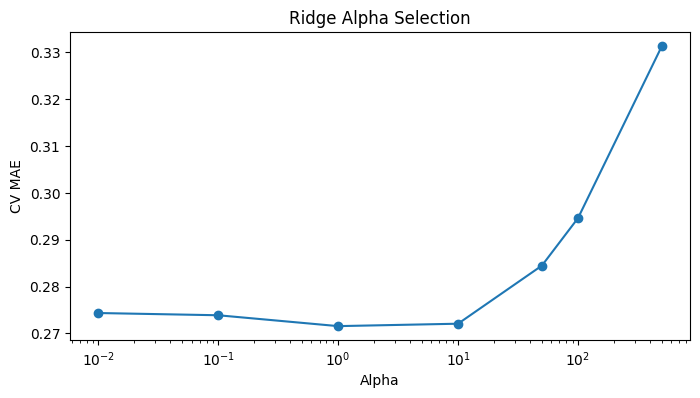

In [94]:
plt.figure(figsize=(8,4))

plt.plot(
    alpha_df["alpha"],
    alpha_df["mae_mean"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("CV MAE")

plt.title(
    "Ridge Alpha Selection"
)

plt.show()

### Nhận xét

Kết quả cho thấy `alpha = 10` đạt MAE thấp nhất trong các giá trị được thử nghiệm.

Điều này cho thấy một mức độ điều chuẩn vừa phải giúp mô hình giảm hiện tượng overfitting mà vẫn giữ được khả năng khai thác tín hiệu từ các đặc trưng đầu vào.

Do đó `alpha = 10` được sử dụng cho tất cả các thí nghiệm **Ridge Regression** tiếp theo.

#### **Select Best Alpha**

In [95]:
BEST_ALPHA = (alpha_df.sort_values("mae_mean").iloc[0]["alpha"])
BEST_ALPHA

np.float64(1.0)

#### **Report Cell**

In [96]:
alpha_df.sort_values("mae_mean").head()

,alpha,mae_mean,mae_std,rmse_mean
2,1.00,0.271567,0.020363,0.369256
3,10.00,0.272083,0.020954,0.367225
1,0.10,0.273886,0.020585,0.371956
0,0.01,0.274364,0.020639,0.372647
4,50.00,0.284482,0.023580,0.380618


### **10.5 Run Ridge Model B**

In [97]:
X_B = model_ready[FEATURES_B]
y = model_ready["log_salary"]

#### **10.5.1 Preprocessor_B**
Vì Feature Set B có:

* categorical features
* numeric features
* skill aggregate features

nên phải tạo preprocessor riêng.

In [98]:
preprocessor_B = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            CATEGORICAL_FEATURES_B
        ),
        (
            "num",
            StandardScaler(),
            NUMERIC_FEATURES_B
        )
    ]
)

#### **10.5.2 Ridge_B Pipeline**

In [99]:
ridge_B = Pipeline(
    steps=[
        ("preprocessor",preprocessor_B),
        ("model",Ridge(alpha=BEST_ALPHA))
    ]
)

#### **10.5.3 Evaluate Ridge B**

In [100]:
X_B = model_ready[FEATURES_B]
y = model_ready["log_salary"]

In [101]:
ridge_B_results = evaluate_model(
    model=ridge_B,
    X=X_B,
    y=y,
    cv=cv,
    stratify_labels=model_ready[
        "salary_bin"
    ]
)

#### **10.5.4 Results**

In [102]:
ridge_B_results

,fold,mae,rmse
0,1,0.252948,0.323393
1,2,0.261470,0.392437
2,3,0.300024,0.424791
3,4,0.247939,0.324281
4,5,0.275324,0.359754


In [103]:
ridge_B_results[["mae","rmse"]].agg(["mean","std"])

,mae,rmse
mean,0.267541,0.364931
std,0.020915,0.044001


**Nhận xét:** 

Ridge B đạt **MAE = 0.268**, cải thiện thêm khoảng **1.8%** so với Ridge A (**0.273**).

Mức cải thiện không lớn nhưng nhất quán, cho thấy các đặc trưng được tổng hợp từ skill vẫn mang thêm thông tin dự đoán lương ngoài metadata của công việc.

Điều này cung cấp bằng chứng rằng pipeline trích xuất và chuẩn hóa skill đã tạo ra giá trị bổ sung cho bài toán salary prediction.

#### **10.6 So sánh Ridge A và Ridge B**

In [104]:
comparison_df = pd.DataFrame(
    [
        {
            "model": "Global Median",
            "mae": baseline_df["mae"].mean(),
            "rmse": baseline_df["rmse"].mean()
        },
        {
            "model": "Median by Title",
            "mae": baseline_title_df["mae"].mean(),
            "rmse": baseline_title_df["rmse"].mean()
        },
        {
            "model": "Ridge A",
            "mae": ridge_A_results["mae"].mean(),
            "rmse": ridge_A_results["rmse"].mean()
        },
        {
            "model": "Ridge B",
            "mae": ridge_B_results["mae"].mean(),
            "rmse": ridge_B_results["rmse"].mean()
        }
    ]
)

comparison_df.sort_values("mae")

,model,mae,rmse
3,Ridge B,0.267541,0.364931
2,Ridge A,0.271567,0.369256
1,Median by Title,0.434313,0.613038
0,Global Median,0.493206,0.660563


## **SECTION 11 - Thử nghiệm Top-K Skills**

Mục tiêu của phần này là đánh giá liệu việc bổ sung các đặc trưng one-hot biểu diễn Top-K kỹ năng phổ biến nhất có giúp cải thiện khả năng dự đoán lương hay không.

Do các kỹ năng chuyên môn thường mang nhiều thông tin liên quan đến mức lương hơn so với kỹ năng mềm, nhóm Soft Skill được loại bỏ trước khi thực hiện các thí nghiệm Top-K.

Nhiều giá trị K khác nhau được đánh giá thông qua cross-validation để xác định số lượng kỹ năng phù hợp nhất.

### **11.1 Tạo dataset loại Soft Skill**

Để đánh giá ảnh hưởng của các kỹ năng chuyên môn đối với bài toán dự đoán lương, nhóm Soft Skill được loại bỏ khỏi tập dữ liệu kỹ năng.

Tập dữ liệu mới sẽ được sử dụng để xây dựng các đặc trưng Top-K và so sánh với phiên bản sử dụng toàn bộ kỹ năng.

In [105]:
skills_no_soft = skills[skills["category"] != "Soft Skill"].copy()
print("Original:",len(skills))
print("Without Soft Skill:",len(skills_no_soft))

Original: 56335
Without Soft Skill: 47595


### **11.2 Xem Top 30 mới**

In [106]:
(skills_no_soft["final_canonical"].value_counts().head(30))

final_canonical
Domain Knowledge Other                        1288
Tool & Platform Other                         1088
Infrastructure & DevOps Other                 1041
Engineering Concepts & Methodologies Other    1021
Framework / Library Other                      557
python                                         546
AI/ML/Data Other                               538
Other Other                                    534
agile                                          494
sql                                            456
java                                           452
git                                            425
ci cd                                          420
Testing & QA Other                             416
restful api                                    387
docker                                         384
aws                                            352
javascript                                     344
microservices                                  312
Embedded & Firm

### **11.3 Hàm benchmark cho FEATURES_B**

In [107]:
# Xác định danh sách feature cho Tập B
X_B = model_ready[FEATURES_B]
y = model_ready["log_salary"]

# Tự động phân loại cột để đưa vào Preprocessor
# Cột Categorical là cột có kiểu dữ liệu object (chuỗi)
# Cột Numeric là các cột còn lại (số năm kinh nghiệm, n_skills, cat_counts...)
CATEGORICAL_FEATURES_B = [c for c in FEATURES_B if X_B[c].dtype == 'object']
NUMERIC_FEATURES_B = [c for c in FEATURES_B if c not in CATEGORICAL_FEATURES_B]

#### **11.3.1 Chạy benchmark**

In [108]:
# 1. Định nghĩa bộ tiền xử lý (Preprocessor)
preprocessor_B = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES_B),
        ("num", StandardScaler(), NUMERIC_FEATURES_B)
    ]
)

# 2. Đóng gói Pipeline
ridge_B = Pipeline(
    steps=[
        ("preprocessor", preprocessor_B),
        ("model", Ridge(alpha=BEST_ALPHA))
    ]
)

# 3. Chạy đánh giá (Sử dụng hàm từ src/evaluation.py)
ridge_B_results = evaluate_model(
    model=ridge_B,
    X=X_B,
    y=y,
    cv=cv,
    stratify_labels=model_ready["salary_bin"]
)

# 4. Hiển thị kết quả tóm tắt
print("Kết quả Ridge B (Mean & Std):")
display(ridge_B_results[["mae", "rmse"]].agg(["mean", "std"]))

Kết quả Ridge B (Mean & Std):


,mae,rmse
mean,0.267541,0.364931
std,0.020915,0.044001


### **11.4 Hàm benchmark cho FEATURES_A**

In [109]:
def evaluate_topk_A(k, skills_df):
    # 1. Lấy ma trận kỹ năng Top-K từ src
    skill_matrix, topk_cols = get_skill_matrix(skills_df, k=k)
    
    # 2. Merge vào dữ liệu chính
    model_k = model_ready.merge(skill_matrix, on="job_id", how="left")
    model_k[topk_cols] = model_k[topk_cols].fillna(0)
    
    # 3. Xác định danh sách feature (Metadata Set A + Top-K Skills)
    feature_cols = FEATURES_A + topk_cols
    X = model_k[feature_cols]
    
    # 4. Tự động phân loại cột
    cat_cols = [c for c in feature_cols if X[c].dtype == "object"]
    num_cols = [c for c in feature_cols if c not in cat_cols]
    
    # 5. Định nghĩa Pipeline
    ridge_topk = Pipeline([
        ("preprocessor", ColumnTransformer([
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
            ("num", StandardScaler(), num_cols)
        ])),
        ("model", Ridge(alpha=10))
    ])

    # 6. Gọi hàm đánh giá từ src/evaluation.py
    results = evaluate_model(
        model=ridge_topk, 
        X=X, 
        y=y, 
        cv=cv,
        stratify_labels=model_ready["salary_bin"]
    )

    return {
        "k": k,
        "mae": results["mae"].mean(),
        "rmse": results["rmse"].mean()
    }

#### **11.4.1 Chạy benchmark**

In [110]:
k_values = [
    25,
    50,
    75,
    100,
    150,
    200
]
topk_A_results = []
for k in k_values:
    res = evaluate_topk_A(k, skills_no_soft)
    topk_A_results.append(res)

topk_A_df = pd.DataFrame(topk_A_results)
display(topk_A_df.sort_values("mae"))

,k,mae,rmse
0,25,0.270950,0.366896
1,50,0.272167,0.369890
2,75,0.274411,0.374561
3,100,0.279023,0.380481
4,150,0.292524,0.397158
5,200,0.301344,0.407249


#### **11.4.2 Visualization**

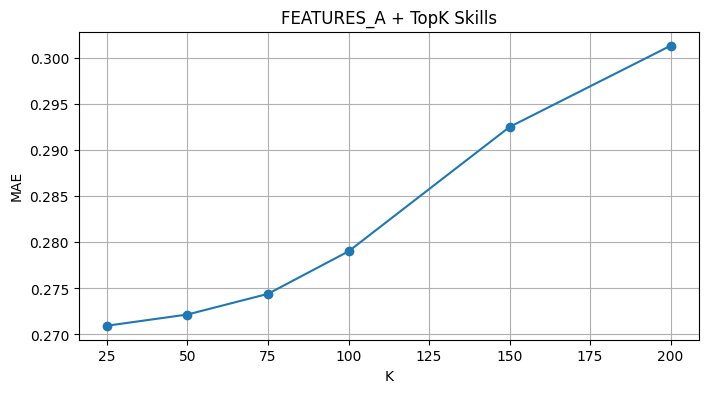

In [111]:
plt.figure(figsize=(8,4))
plt.plot(topk_A_df["k"],topk_A_df["mae"],marker="o")
plt.xlabel("K")
plt.ylabel("MAE")
plt.title("FEATURES_A + TopK Skills")
plt.grid(True)
plt.show()

### **11.5 So sánh với Ridge A và Ridge B**

In [112]:
comparison = pd.DataFrame({"model": ["Ridge A","Ridge B","TopK Best"],
    "mae": [
        0.272664,
        0.267811,
        topk_A_df["mae"].min()
    ]
})
comparison.sort_values("mae")

,model,mae
1,Ridge B,0.267811
2,TopK Best,0.270950
0,Ridge A,0.272664


### **11.6 Kết luận cuối cùng về biểu diễn kỹ năng**

1. Việc bổ sung Top-25 kỹ năng phổ biến nhất giúp cải thiện nhẹ hiệu năng của Ridge A.

2. Khi tăng giá trị K, hiệu năng mô hình giảm dần một cách nhất quán. Điều này cho thấy việc bổ sung quá nhiều kỹ năng hiếm làm tăng độ thưa của dữ liệu và không mang lại thêm tín hiệu hữu ích cho mô hình Ridge.

3. Bộ đặc trưng **Feature Set B** đạt kết quả tốt hơn tất cả các phiên bản sử dụng Top-K Skills.

### **Quyết định cuối cùng**

Mô hình cuối cùng sử dụng các đặc trưng kỹ năng tổng hợp (**Feature Set B**), bao gồm:

- số lượng kỹ năng,
- số lượng kỹ năng theo nhóm,
- số lượng kỹ năng theo mức độ,
- các đặc trưng kinh nghiệm liên quan đến kỹ năng.

Các đặc trưng one-hot biểu diễn Top-K kỹ năng không được sử dụng trong mô hình cuối cùng vì không mang lại cải thiện đáng kể so với phương pháp tổng hợp đặc trưng.

## **SECTION 12 - LightGBM (Feature Set A)**

**Mục tiêu:**

Kiểm tra liệu mô hình phi tuyến có khai thác MetaDatat tốt hơn Ridge hay không.

### **12.1 Cấu hình LightGBM cơ bản**

Một mô hình `LightGBM` đơn giản được huấn luyện trên **Feature Set A**.

Ở giai đoạn này, chưa thực hiện tối ưu siêu tham số (hyperparameter tuning).

**Mục tiêu** là đánh giá liệu một mô hình dựa trên cây quyết định (tree-based model) có thể vượt qua Ridge Regression khi sử dụng cùng một tập đặc trưng hay không.

Do `LightGBM` có khả năng học các mối quan hệ phi tuyến và tương tác giữa các đặc trưng, mô hình này được kỳ vọng sẽ khai thác tốt hơn các tín hiệu tiềm ẩn trong dữ liệu so với **Ridge Regression**.

In [113]:
# Tự động lấy danh sách cột categorical từ FEATURES_A
cat_features_lgbm = [c for c in FEATURES_A if c != "experience_years"]

lgbm_A = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features_lgbm),
        ("num", StandardScaler(), ["experience_years"])
    ])),
    ("model", LGBMRegressor(random_state=42, n_estimators=300))
])

### **12.2 Evaluation**

Cross Validation Evaluation

In [114]:
X_A = model_ready[FEATURES_A]
y = model_ready["log_salary"]
lgbm_A_results = evaluate_model(
    model=lgbm_A,
    X=X_A,
    y=y,
    cv=cv,
    stratify_labels=model_ready[
        "salary_bin"
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 113
[LightGBM] [Info] Number of data points in the train set: 1180, number of used features: 51
[LightGBM] [Info] Start training from score 3.084161
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 110
[LightGBM] [Info] Number of data points in the train set: 1181, number of used features: 49
[LightGBM] [Info] Start training from score 3.095571
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000349 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, y

### **12.3 Fold Results**

In [115]:
lgbm_A_results

,fold,mae,rmse
0,1,0.247260,0.321705
1,2,0.275768,0.399106
2,3,0.302037,0.439855
3,4,0.260478,0.347146
4,5,0.267715,0.349952


### **12.4 Summary**

In [116]:
lgbm_A_results[["mae","rmse"]].agg(["mean","std"])

,mae,rmse
mean,0.270651,0.371553
std,0.020436,0.047359


### **12.5 Compare với Ridge**

In [117]:
comparison_lgbm_A = pd.DataFrame(
    [
        {
            "model": "Baseline Median",
            "mae": baseline_df["mae"].mean(),
            "rmse": baseline_df["rmse"].mean()
        },
        {
            "model": "Baseline Title",
            "mae": baseline_title_df["mae"].mean(),
            "rmse": baseline_title_df["rmse"].mean()
        },
        {
            "model": "Ridge A",
            "mae": ridge_A_results["mae"].mean(),
            "rmse": ridge_A_results["rmse"].mean()
        },
        {
            "model": "LightGBM A",
            "mae": lgbm_A_results["mae"].mean(),
            "rmse": lgbm_A_results["rmse"].mean()
        }
    ]
)

comparison_lgbm_A.sort_values("mae")

,model,mae,rmse
3,LightGBM A,0.270651,0.371553
2,Ridge A,0.271567,0.369256
1,Baseline Title,0.434313,0.613038
0,Baseline Median,0.493206,0.660563


### **12.6 Visualization**

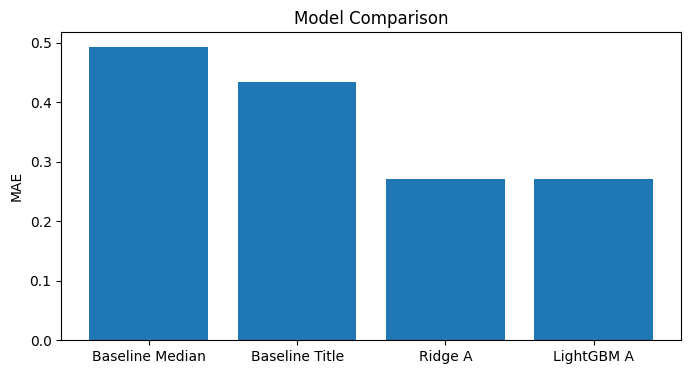

In [118]:
plt.figure(figsize=(8,4))
plt.bar(comparison_lgbm_A["model"],comparison_lgbm_A["mae"])
plt.ylabel("MAE")
plt.title("Model Comparison")
plt.show()

### **12.7 Nhận xét**

**Nhận xét:**

`LightGBM A` đạt **MAE = 0.271** và **RMSE = 0.372**, nhỉnh hơn `Ridge A` về **MAE** nhưng kém hơn một chút về **RMSE**.

Tuy nhiên, mức chênh lệch giữa hai mô hình là rất nhỏ (MAE chỉ cải thiện khoảng 0.001), cho thấy Feature Set A đã cung cấp phần lớn tín hiệu dự đoán cần thiết cho bài toán.

Kết quả này cho thấy việc sử dụng mô hình phi tuyến phức tạp hơn chưa mang lại lợi ích đáng kể khi chỉ sử dụng các đặc trưng metadata. Do đó, chất lượng đặc trưng (feature engineering) có thể đóng vai trò quan trọng hơn việc gia tăng độ phức tạp của mô hình ở giai đoạn này.

## **SECTION 13 - LightGBM (Feature Set B)**

**Mục tiêu:**

Metadata
+
Skill Aggregate Features
+
LightGBM

### **13.1 Feature Matrix**

Feature Set B includes:

- Metadata features
- Skill count features
- Skill category counts
- Skill level counts
- Experience requirement aggregates

In [119]:
X_B = model_ready[FEATURES_B]
y = model_ready["log_salary"]
print(X_B.shape)

(1476, 29)


### **13.2 Xác định categorical / numerical columns**

In [120]:
cat_cols_B = [c for c in FEATURES_B if X_B[c].dtype == "object"]
num_cols_B = [c for c in FEATURES_B if c not in cat_cols_B]
print("Categorical:", len(cat_cols_B))
print("Numerical:", len(num_cols_B))

Categorical: 6
Numerical: 23


### **13.3 Pipeline LightGBM B**

Một mô hình LightGBM được huấn luyện trên Feature Set B, bao gồm các đặc trưng metadata và các đặc trưng được xây dựng từ dữ liệu kỹ năng.

Quy trình cross-validation 5-fold được giữ nguyên nhằm đảm bảo khả năng so sánh trực tiếp với các mô hình đã đánh giá trước đó.

Thí nghiệm này nhằm kiểm tra liệu mô hình cây quyết định có thể khai thác hiệu quả hơn các đặc trưng kỹ năng so với Ridge Regression hay không.

In [121]:
lgbm_B = Pipeline([
    (
        "preprocessor",
        ColumnTransformer([
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                cat_cols_B
            ),
            (
                "num",
                StandardScaler(),
                num_cols_B
            )
        ])
    ),
    (
        "model",
        LGBMRegressor(
            random_state=42,
            n_estimators=300
        )
    )
])

### **13.4 Cross Validation**

In [122]:
lgbm_B_results = evaluate_model(
    model=lgbm_B,
    X=X_B,
    y=y,
    cv=cv,
    stratify_labels=model_ready[
        "salary_bin"
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000201 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 477
[LightGBM] [Info] Number of data points in the train set: 1180, number of used features: 73
[LightGBM] [Info] Start training from score 3.084161
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000455 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 479
[LightGBM] [Info] Number of data points in the train set: 1181, number of used features: 71
[LightGBM] [Info] Start training from score 3.095571
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000517 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 478
[LightGBM] [Info] Number of data points in the train set: 118

### **13.5 Fold Results**

In [123]:
lgbm_B_results

,fold,mae,rmse
0,1,0.261240,0.325240
1,2,0.272184,0.399546
2,3,0.295967,0.443088
3,4,0.263303,0.341214
4,5,0.274669,0.353634


### **13.6 Summary Statistics**

In [124]:
lgbm_B_results[["mae","rmse"]].agg(["mean","std"])

,mae,rmse
mean,0.273473,0.372544
std,0.013804,0.048173


### **13.7 Compare với các model trước**

In [125]:
comparison_models = pd.DataFrame(
    [
        {
            "model": "Baseline Median",
            "mae": baseline_df["mae"].mean(),
            "rmse": baseline_df["rmse"].mean()
        },
        {
            "model": "Baseline Title",
            "mae": baseline_title_df["mae"].mean(),
            "rmse": baseline_title_df["rmse"].mean()
        },
        {
            "model": "Ridge A",
            "mae": ridge_A_results["mae"].mean(),
            "rmse": ridge_A_results["rmse"].mean()
        },
        {
            "model": "LightGBM A",
            "mae": lgbm_A_results["mae"].mean(),
            "rmse": lgbm_A_results["rmse"].mean()
        },
        {
            "model": "Ridge B",
            "mae": ridge_B_results["mae"].mean(),
            "rmse": ridge_B_results["rmse"].mean()
        },
        {
            "model": "LightGBM B",
            "mae": lgbm_B_results["mae"].mean(),
            "rmse": lgbm_B_results["rmse"].mean()
        }
    ]
)

comparison_models.sort_values("mae")

,model,mae,rmse
4,Ridge B,0.267541,0.364931
3,LightGBM A,0.270651,0.371553
2,Ridge A,0.271567,0.369256
5,LightGBM B,0.273473,0.372544
1,Baseline Title,0.434313,0.613038
0,Baseline Median,0.493206,0.660563


### **13.8 Visualization**

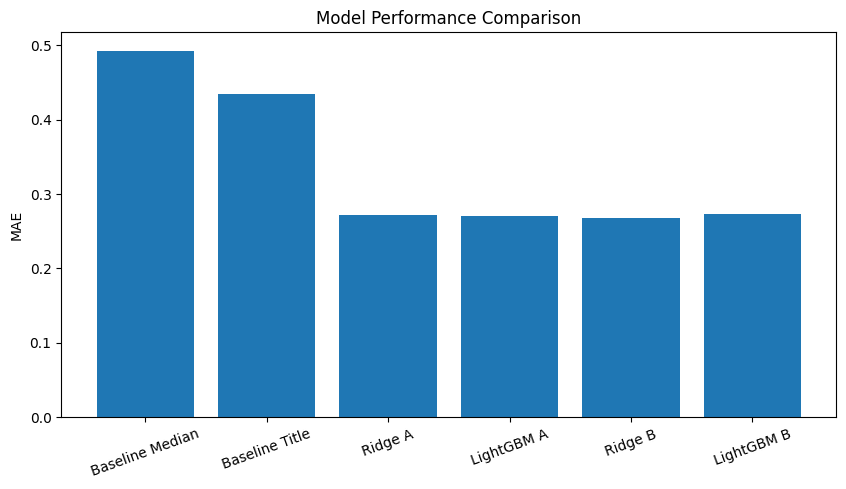

In [126]:
plt.figure(figsize=(10,5))
plt.bar(comparison_models["model"],comparison_models["mae"])
plt.ylabel("MAE")
plt.title("Model Performance Comparison")
plt.xticks(rotation=20)
plt.show()

**Kết luận:**

Các đặc trưng metadata cung cấp phần lớn tín hiệu dự đoán mức lương.

Việc bổ sung các đặc trưng tổng hợp từ skill (Feature Set B) giúp cải thiện hiệu năng của mô hình `Ridge Regression`, với **MAE giảm từ 0.2716 xuống 0.2675** và **RMSE** cũng giảm tương ứng. Điều này cho thấy các thông tin kỹ năng được trích xuất từ pipeline xử lý skill đã mang lại giá trị bổ sung cho bài toán dự đoán lương.

Tuy nhiên, khi sử dụng `LightGBM`, việc bổ sung các đặc trưng skill tổng hợp không mang lại cải thiện hiệu năng. `LightGBM B` đạt **MAE = 0.2735**, thấp hơn so với `LightGBM A` (**MAE = 0.2707**).

Kết quả này cho thấy mối quan hệ giữa các đặc trưng skill tổng hợp và mức lương chủ yếu mang tính tuyến tính. Do đó, `Ridge Regression` có khả năng khai thác hiệu quả các tín hiệu này thông qua cơ chế regularization, trong khi mô hình cây tăng cường như `LightGBM` không thu được thêm nhiều lợi ích từ cùng tập đặc trưng.

Trong toàn bộ các mô hình được đánh giá, **Ridge B đạt kết quả tốt nhất với MAE = 0.2675 và RMSE = 0.3649**, do đó được lựa chọn làm mô hình cuối cùng cho hệ thống dự đoán lương.

## **SECTION 14 - Model Comparison & Selection**

In [127]:
final_results = pd.DataFrame({
    "model": [
        "Baseline Median",
        "Baseline Title",
        "Ridge A",
        "Ridge B",
        "LightGBM A",
        "LightGBM B"
    ],
    "mae": [
        baseline_df["mae"].mean(),
        baseline_title_df["mae"].mean(),
        ridge_A_results["mae"].mean(),
        ridge_B_results["mae"].mean(),
        lgbm_A_results["mae"].mean(),
        lgbm_B_results["mae"].mean()
    ],
    "rmse": [
        baseline_df["rmse"].mean(),
        baseline_title_df["rmse"].mean(),
        ridge_A_results["rmse"].mean(),
        ridge_B_results["rmse"].mean(),
        lgbm_A_results["rmse"].mean(),
        lgbm_B_results["rmse"].mean()
    ]
})

final_results.sort_values("mae")

,model,mae,rmse
3,Ridge B,0.267541,0.364931
4,LightGBM A,0.270651,0.371553
2,Ridge A,0.271567,0.369256
5,LightGBM B,0.273473,0.372544
1,Baseline Title,0.434313,0.613038
0,Baseline Median,0.493206,0.660563


### **14.1 FINAL COMPARISON (ORIGINAL VS CLEANED INDUSTRY)**

In [128]:
# --- SECTION 17: FINAL COMPARISON (TỰ ĐỘNG CẬP NHẬT) ---

# 1. Điền thủ công các con số từ Report cũ (Industry gốc) vào đây
original_industry_mae = {
    "Ridge A": 0.272664, 
    "Ridge B": 0.267811, 
    "LGBM A": 0.271009, 
    "LGBM B": 0.275750
}

cleaned_industry_mae = {
    "Ridge A": ridge_A_results["mae"].mean(),
    "Ridge B": ridge_B_results["mae"].mean(),
    "LGBM A": lgbm_A_results["mae"].mean(),
    "LGBM B": lgbm_B_results["mae"].mean()
}

# 2. Tạo bảng so sánh
comparison_data = []
for model_name in original_industry_mae.keys():
    mae_old = original_industry_mae[model_name]
    mae_new = cleaned_industry_mae[model_name]
    improvement = (mae_old - mae_new) / mae_old * 100
    
    comparison_data.append({
        "Model": model_name,
        "Industry Gốc (56 cats)": mae_old,
        "Industry Mới (15 cats)": mae_new,
        "Cải thiện (%)": improvement
    })

# 3. Thêm Baseline (không đổi) để bảng đầy đủ
baselines = [
    {"Model": "Baseline Median", "Industry Gốc (56 cats)": baseline_df["mae"].mean(), "Industry Mới (15 cats)": baseline_df["mae"].mean(), "Cải thiện (%)": 0.0},
    {"Model": "Baseline Title", "Industry Gốc (56 cats)": baseline_title_df["mae"].mean(), "Industry Mới (15 cats)": baseline_title_df["mae"].mean(), "Cải thiện (%)": 0.0}
]

final_df = pd.concat([pd.DataFrame(comparison_data), pd.DataFrame(baselines)], ignore_index=True)

print("BẢNG ĐỐI CHIẾU HIỆU NĂNG:")
display(final_df.sort_values("Industry Mới (15 cats)"))

BẢNG ĐỐI CHIẾU HIỆU NĂNG:


,Model,Industry Gốc (56 cats),Industry Mới (15 cats),Cải thiện (%)
1,Ridge B,0.267811,0.267541,0.100843
2,LGBM A,0.271009,0.270651,0.131975
0,Ridge A,0.272664,0.271567,0.402214
3,LGBM B,0.275750,0.273473,0.825890
5,Baseline Title,0.434313,0.434313,0.000000
4,Baseline Median,0.493206,0.493206,0.000000


## **SECTION 15 - Train Final Model**

Train Ridge B trên toàn bộ dữ liệu

In [129]:
final_model = ridge_B.fit(X_B,y)

### **15.1 - Feature Importance**

Lấy tên feature sau preprocessing

In [130]:
feature_names = (
    final_model.named_steps[
        "preprocessor"
    ]
    .get_feature_names_out()
)

coef = (
    final_model.named_steps[
        "model"
    ]
    .coef_
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "abs_coef": np.abs(coef)
})

importance_df = (
    importance_df
    .sort_values(
        "abs_coef",
        ascending=False
    )
)

importance_df.head(30)

,feature,coef,abs_coef
46,cat__job_level_Intern,-0.951808,0.951808
119,cat__standardized_title_Power Apps Developer,0.690370,0.690370
6,cat__location_Foreign:Japan,0.653258,0.653258
88,cat__standardized_title_GIS Developer,-0.464319,0.464319
45,cat__job_level_Giám đốc,0.400197,0.400197
97,cat__standardized_title_IT Account Manager,0.349590,0.349590
2,cat__location_An Giang,-0.342821,0.342821
55,cat__standardized_title_AI Data Annotator,-0.340224,0.340224
74,cat__standardized_title_Data Scientist,0.320865,0.320865
36,cat__education_Cao học trở lên,-0.318339,0.318339


#### **Plot Top 30**

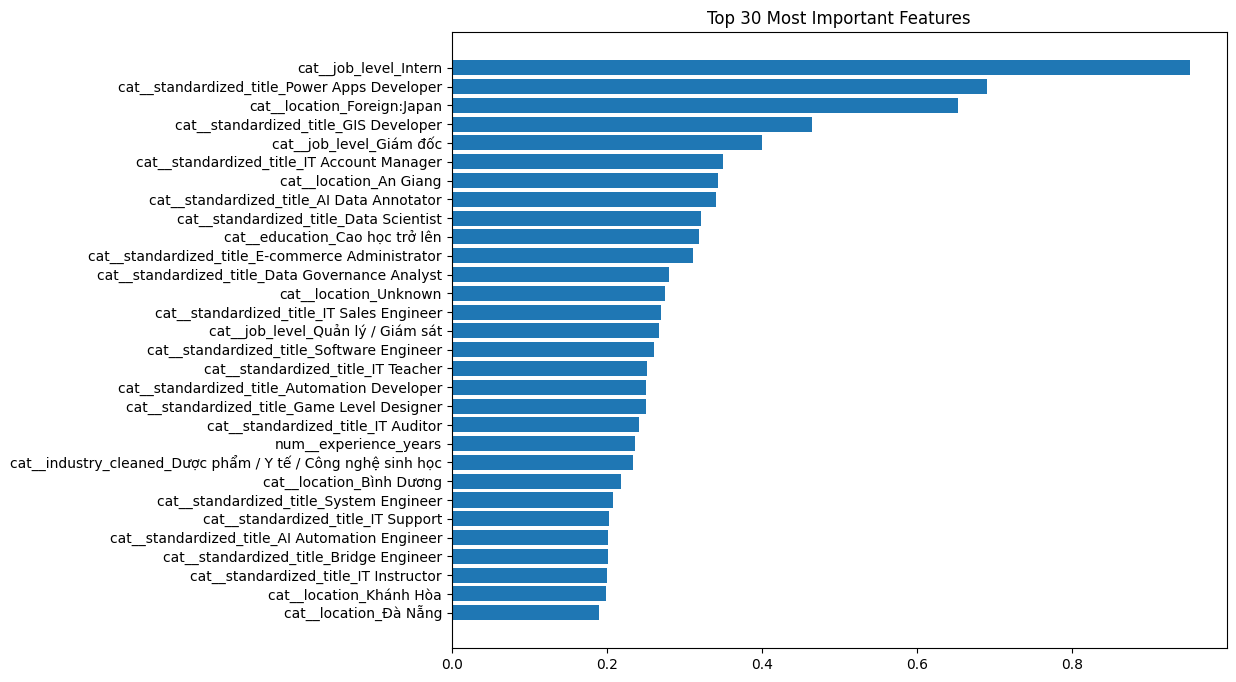

In [131]:
top30 = (importance_df.head(30).sort_values("abs_coef"))
plt.figure(figsize=(10,8))
plt.barh(top30["feature"], top30["abs_coef"])
plt.title("Top 30 Most Important Features")
plt.show()

**Nhận xét:**

- **Job Level** là nhóm đặc trưng quan trọng nhất trong mô hình. Các biến liên quan đến cấp bậc công việc như Intern, Giám đốc và Quản lý/Giám sát đều nằm trong nhóm đặc trưng có mức độ quan trọng cao nhất, cho thấy cấp bậc công việc có ảnh hưởng lớn đến dự đoán lương.

- **Standardized Title** đóng góp đáng kể vào hiệu năng mô hình. Nhiều chức danh như Power Apps Developer, DS Developer, IT Account Manager, AI Data Annotator và Data Governance Analyst xuất hiện trong Top 30 đặc trưng quan trọng nhất, cho thấy tên vị trí công việc chứa nhiều thông tin về mức lương.

- **Location** là nguồn tín hiệu quan trọng. Các biến như Foreign: Japan, An Giang, Bình Dương, Khánh Hòa và Đà Nẵng đều xuất hiện trong danh sách đặc trưng quan trọng, phản ánh sự khác biệt về phân bố lương theo địa điểm làm việc.

- **Experience Years** là một trong những đặc trưng số có mức độ quan trọng cao, cho thấy kinh nghiệm làm việc đóng vai trò đáng kể trong quá trình dự đoán lương.

- **Education** cũng xuất hiện trong nhóm đặc trưng quan trọng, đặc biệt là trình độ từ Cao học trở lên.

- **Industry** tiếp tục cung cấp thông tin bổ sung cho mô hình. Một số nhóm ngành như Dược phẩm/Y tế/Công nghệ sinh học nằm trong Top 30 đặc trưng quan trọng nhất.

Nhìn chung, mô hình sử dụng đồng thời thông tin về cấp bậc công việc, chức danh, kinh nghiệm, địa điểm, học vấn và ngành nghề để dự đoán mức lương. Trong đó, cấp bậc công việc và chức danh công việc là các nguồn tín hiệu nổi bật nhất.

### **15.2 - Out-of-Fold Prediction**

Tạo prediction CV thật sự


In [132]:
# Tạo oof thủ công
oof_pred = np.zeros(len(model_ready))
for train_idx, valid_idx in cv.split(X_B, model_ready["salary_bin"]):
    X_train = X_B.iloc[train_idx]
    X_valid = X_B.iloc[valid_idx]
    y_train = y.iloc[train_idx]
    model = clone(ridge_B)
    model.fit(X_train, y_train)
    oof_pred[valid_idx] = (model.predict(X_valid))

In [133]:
# Check
len(oof_pred)

1476

#### **Residual**

In [134]:
residual_df = pd.DataFrame({"actual": y,"pred": oof_pred})
residual_df["residual"] = (
    residual_df["actual"]
    -
    residual_df["pred"]
)

#### **Plot Actual vs Predicted**

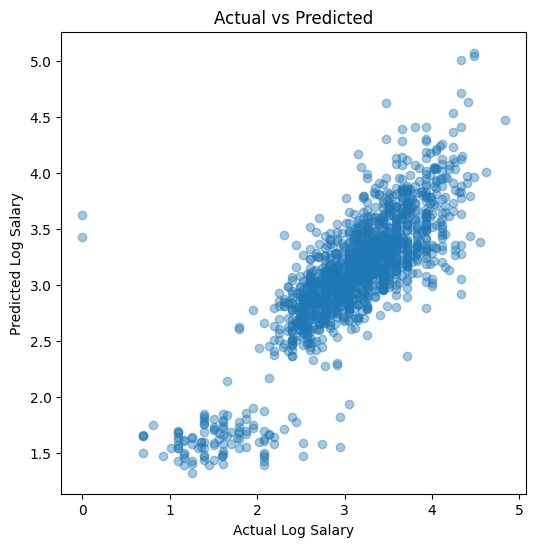

In [135]:
plt.figure(figsize=(6,6))
plt.scatter(
    residual_df["actual"],
    residual_df["pred"],
    alpha=0.4
)
plt.xlabel("Actual Log Salary")
plt.ylabel("Predicted Log Salary")
plt.title("Actual vs Predicted")
plt.show()

#### **Residual Histogram**

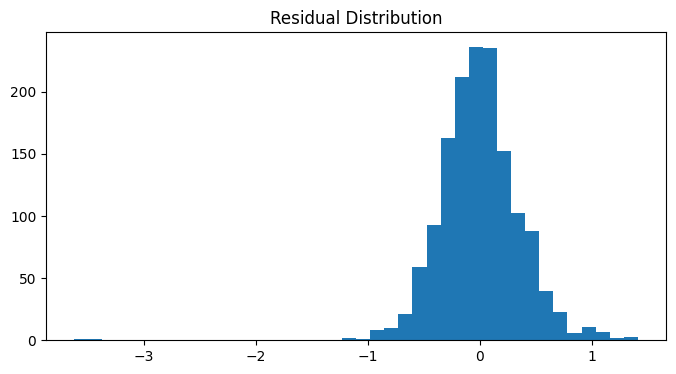

In [136]:
plt.figure(figsize=(8,4))
plt.hist(
    residual_df["residual"],
    bins=40
)
plt.title("Residual Distribution")
plt.show()

#### **Residual vs Prediction**

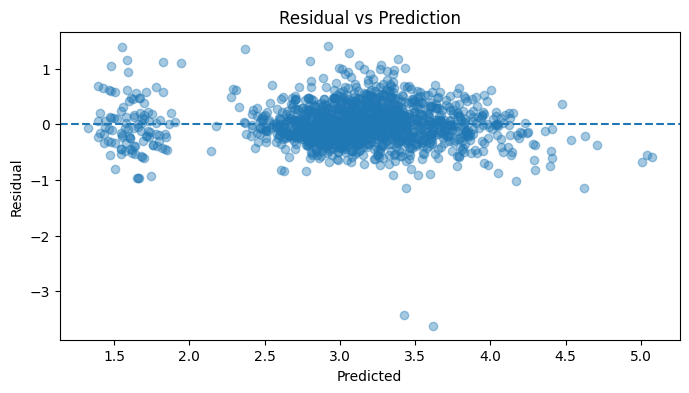

In [137]:
plt.figure(figsize=(8,4))
plt.scatter(
    residual_df["pred"],
    residual_df["residual"],
    alpha=0.4
)
plt.axhline(0,linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual vs Prediction")
plt.show()

### Phân tích phần dư (Residual Analysis)

Các phần dư phân bố tương đối cân đối quanh đường 0, cho thấy mô hình không có xu hướng dự đoán cao hơn hoặc thấp hơn một cách có hệ thống trên toàn bộ tập dữ liệu.

Phần lớn quan sát tập trung trong vùng lân cận giá trị 0, cho thấy sai số dự đoán nhìn chung được kiểm soát ở mức hợp lý đối với đa số tin tuyển dụng.

Biên độ phần dư có xu hướng tăng nhẹ ở một số vùng dự đoán, cho thấy độ chính xác của mô hình không hoàn toàn đồng nhất trên toàn bộ miền giá trị mục tiêu. Tuy nhiên, không xuất hiện mẫu hình rõ rệt hoặc xu hướng phi tuyến mạnh trong phần dư.

Ngoài ra vẫn tồn tại một số điểm có sai số rất lớn (outliers), đặc biệt là một vài trường hợp có phần dư âm đáng kể. Điều này cho thấy vẫn có những tin tuyển dụng mà mức lương chịu ảnh hưởng bởi các yếu tố chưa được mô hình hóa đầy đủ từ metadata và các đặc trưng kỹ năng hiện có.

Nhìn chung, phân bố phần dư cho thấy mô hình hoạt động tương đối ổn định và không vi phạm nghiêm trọng các giả định cơ bản của mô hình hồi quy.

**Xem top lỗi lớn nhất**

In [138]:
worst_cases = (residual_df.assign(
        abs_error=lambda x:
        x["residual"].abs()
    )
    .sort_values(
        "abs_error",
        ascending=False
    )
)

worst_cases.head(20)

,actual,pred,residual,abs_error
550,0.000000,3.621221,-3.621221,3.621221
974,0.000000,3.426224,-3.426224,3.426224
14,4.330733,2.919925,1.410808,1.410808
410,2.944439,1.551898,1.392541,1.392541
1199,3.713572,2.367805,1.345767,1.345767
615,4.330733,3.057724,1.273009,1.273009
1473,4.551242,3.384704,1.166538,1.166538
1269,2.740840,1.585286,1.155554,1.155554
1464,3.473208,4.622753,-1.149545,1.149545
512,2.302585,3.442809,-1.140224,1.140224


**Join lại với job_info**

In [139]:
worst_jobs = (
    model_ready[
        [
            "job_id",
            "job_title",
            "company",
            "source",
            "avg_salary",
            "experience_years"
        ]
    ]
    .join(
        worst_cases[
            [
                "pred",
                "actual",
                "residual",
                "abs_error"
            ]
        ]
    )
)

worst_jobs.head(20)

,job_id,job_title,company,source,avg_salary,experience_years,pred,actual,residual,abs_error
0,1,Lập Trình Viên (.Net) - Không Yêu Cầu Kinh Ngh...,Công ty cổ phần công nghệ và giải pháp trực tu...,topcv,14.00,2.0,3.253140,2.708050,-0.545089,0.545089
1,3,Backend Lead Engineer,CÔNG TY TNHH LEVER SPHERE VIỆT NAM,topcv,60.00,3.0,3.443025,4.110874,0.667849,0.667849
2,4,Lập Trình Viên Nodejs Đi Làm Ngay Tại Hà Nội,Công ty cổ phần giải pháp MKT,topcv,30.00,1.0,2.958677,3.433987,0.475310,0.475310
3,5,Kỹ Sư Tư Vấn Mạng/ Presale Network Engineer,Công ty Cổ phần Viễn thông - Tin học Bưu điện ...,topcv,45.00,3.0,3.286521,3.828641,0.542120,0.542120
4,6,Nhân Viên Kỹ Thuật IT - Dự Án Xây Dựng Cao Tần...,"CÔNG TY CỔ PHẦN XÂY DỰNG, THƯƠNG MẠI VÀ VẬT LI...",topcv,15.00,2.0,2.760668,2.772589,0.011921,0.011921
5,7,Senior Backend Developer (Node.Js) Lương Upto 35M,Công ty TNHH Phần mềm Nhân Hòa,topcv,35.00,3.0,3.461517,3.583519,0.122002,0.122002
6,8,"Fullstack Software Engineers (Full-Time, Hybir...",CÔNG TY TNHH VIỆC CÓ,topcv,18.00,2.0,2.875914,2.944439,0.068525,0.068525
7,9,AI-Augmented Quality Engineer – Dự Án Capigo,CÔNG TY TNHH SALAMAN VIỆT NAM,topcv,27.50,3.0,3.213137,3.349904,0.136767,0.136767
8,10,"Kỹ Sư Mạng , Bảo Mật",CÔNG TY TNHH CÔNG NGHỆ THÔNG TIN VÀ TRUYỀN THÔ...,topcv,23.50,2.0,3.157272,3.198673,0.041401,0.041401
9,11,Kỹ Sư Hệ Thống ( Linux),CÔNG TY TNHH CÔNG NGHỆ THÔNG TIN VÀ TRUYỀN THÔ...,topcv,23.50,3.0,3.166326,3.198673,0.032347,0.032347


## **Section 16 - Export**

In [140]:
# Lưu Final model
joblib.dump(final_model,"salary_predictor_1.joblib")

['salary_predictor_1.joblib']

In [142]:
with open("../data/processed/features_wide_1.parquet","rb") as f:
    file_hash = hashlib.md5(f.read()).hexdigest()
print(file_hash)

17a80dfff46eca8b562fffa6b5fa076d


In [143]:
residual_df["residual"].describe()

count    1476.000000
mean       -0.000692
std         0.367143
min        -3.621221
25%        -0.218684
50%        -0.006918
75%         0.198838
max         1.410808
Name: residual, dtype: float64